# NB15 — Teste de Robustez: Correlação Ocupação × TEstadia · Brasil 2025

**Objetivo:** Avaliar se a correlação Spearman entre taxa de ocupação de berço e TEstadia/TEspera  
por porto (calculada em NB13) é robusta à presença de outliers.

**Input:** `ocupacao_testadia_porto_2025.csv` (NB13)  
**Método:** 3 cenários com remoção progressiva de outliers extremos por TEstadia

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import os, warnings

warnings.filterwarnings('ignore')
FIG_DIR = '../outputs/figures/'
CSV_DIR = '../outputs/processed_data/'
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({'figure.dpi': 150, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
print('Setup OK')

Setup OK


---
## 1 — Carregar e Inspecionar Dados

In [2]:
# ── Dataset base (NB13: correlacao ocupacao × TEstadia por porto) ─────────
df_raw = pd.read_csv(CSV_DIR + 'ocupacao_testadia_porto_2025.csv', encoding='utf-8-sig')

print('Dataset completo:')
print(df_raw.sort_values('TEstadia_Med', ascending=False).to_string(index=False))
print()

# Trabalhar apenas com linhas com valores válidos para as 3 variáveis
df = df_raw.dropna(subset=['Taxa_Media_Pct', 'TEstadia_Med', 'TEspera_Med']).copy()
df = df.sort_values('TEstadia_Med', ascending=False).reset_index(drop=True)

print(f'Portos com dados completos: {len(df)}')
print()

# ── Passo 1: Identificar outliers por TEstadia ───────────────────────────
outlier_1 = df.iloc[0]  # maior TEstadia
outlier_2 = df.iloc[1]  # segundo maior

print('=== OUTLIERS POR TEstadia ===')
print(f'1º outlier: {outlier_1["Porto_Canon"]:25s}  TEstadia={outlier_1["TEstadia_Med"]:.0f}h  '
      f'TEspera={outlier_1["TEspera_Med"]:.0f}h  Taxa={outlier_1["Taxa_Media_Pct"]:.1f}%')
print(f'2º outlier: {outlier_2["Porto_Canon"]:25s}  TEstadia={outlier_2["TEstadia_Med"]:.0f}h  '
      f'TEspera={outlier_2["TEspera_Med"]:.0f}h  Taxa={outlier_2["Taxa_Media_Pct"]:.1f}%')
print()
ratio_12 = outlier_1['TEstadia_Med'] / outlier_2['TEstadia_Med']
print(f'TEstadia do 1º outlier é {ratio_12:.1f}× o do 2º → São Francisco do Sul: caso estrutural distinto.')

Dataset completo:
         Porto_Canon  Taxa_Media_Pct  TEstadia_Med  TEspera_Med  N_Atr
São Francisco do Sul       68.885714    239.550000   163.333330    NaN
           Paranaguá       77.000000     98.250000    58.300000 2216.0
               Pecém       61.100000     87.000000    26.683333  385.0
             Itaguaí       60.716667     77.316667    17.616667  578.0
              Santos       60.561818     75.827210    23.725806 4600.0
          Rio Grande       45.573684     62.416667    17.833333  954.0
               Suape       65.718182     54.600000     6.116667  514.0
              Itajaí       45.111111     31.042167    10.750464 1366.0
            Salvador       24.362500     30.050000     2.166667  331.0
      Rio de Janeiro       36.679167     24.091667     1.000000 1135.0

Portos com dados completos: 10

=== OUTLIERS POR TEstadia ===
1º outlier: São Francisco do Sul       TEstadia=240h  TEspera=163h  Taxa=68.9%
2º outlier: Paranaguá                  TEstadia=98h  TEsper

---
## 2 — Três Cenários de Correlação

In [3]:
# ── Função auxiliar ───────────────────────────────────────────────────────
def spearman_pair(data, x_col, y_col):
    sub = data.dropna(subset=[x_col, y_col])
    if len(sub) < 3:
        return np.nan, np.nan, len(sub)
    rho, p = stats.spearmanr(sub[x_col], sub[y_col])
    return round(rho, 3), round(p, 3), len(sub)

def interpret(rho):
    if abs(rho) >= 0.70:
        return 'Robusta — publicável'
    elif abs(rho) >= 0.50:
        return 'Moderada — publicar com ressalva'
    else:
        return 'Frágil — apenas exploratório'

# ── Cenário A: todos os portos ────────────────────────────────────────────
rho_est_A, p_est_A, n_A = spearman_pair(df, 'Taxa_Media_Pct', 'TEstadia_Med')
rho_esp_A, p_esp_A, _   = spearman_pair(df, 'Taxa_Media_Pct', 'TEspera_Med')

# ── Cenário B: excluindo São Francisco do Sul ─────────────────────────────
df_B = df[df['Porto_Canon'] != outlier_1['Porto_Canon']].copy()
rho_est_B, p_est_B, n_B = spearman_pair(df_B, 'Taxa_Media_Pct', 'TEstadia_Med')
rho_esp_B, p_esp_B, _   = spearman_pair(df_B, 'Taxa_Media_Pct', 'TEspera_Med')

# ── Cenário C: excluindo os 2 outliers ────────────────────────────────────
df_C = df[~df['Porto_Canon'].isin([outlier_1['Porto_Canon'], outlier_2['Porto_Canon']])].copy()
rho_est_C, p_est_C, n_C = spearman_pair(df_C, 'Taxa_Media_Pct', 'TEstadia_Med')
rho_esp_C, p_esp_C, _   = spearman_pair(df_C, 'Taxa_Media_Pct', 'TEspera_Med')

# ── Tabela comparativa ────────────────────────────────────────────────────
tab = pd.DataFrame([
    {
        'Cenário':       'A — Todos os portos',
        'n_portos':      n_A,
        'ρ_TEstadia':    rho_est_A,
        'p_TEstadia':    p_est_A,
        'ρ_TEspera':     rho_esp_A,
        'p_TEspera':     p_esp_A,
        'Interp_TEstadia': interpret(rho_est_A),
    },
    {
        'Cenário':       f'B — Sem {outlier_1["Porto_Canon"]}',
        'n_portos':      n_B,
        'ρ_TEstadia':    rho_est_B,
        'p_TEstadia':    p_est_B,
        'ρ_TEspera':     rho_esp_B,
        'p_TEspera':     p_esp_B,
        'Interp_TEstadia': interpret(rho_est_B),
    },
    {
        'Cenário':       f'C — Sem {outlier_1["Porto_Canon"]} e {outlier_2["Porto_Canon"]}',
        'n_portos':      n_C,
        'ρ_TEstadia':    rho_est_C,
        'p_TEstadia':    p_est_C,
        'ρ_TEspera':     rho_esp_C,
        'p_TEspera':     p_esp_C,
        'Interp_TEstadia': interpret(rho_est_C),
    },
])

print('=== TABELA COMPARATIVA — CORRELAÇÕES SPEARMAN ===')
print(tab.to_string(index=False))
print()
print('NOTA: n ≤ 10 em todos os cenários. Correlações indicativas — interpretar com cautela.')

=== TABELA COMPARATIVA — CORRELAÇÕES SPEARMAN ===
                                 Cenário  n_portos  ρ_TEstadia  p_TEstadia  ρ_TEspera  p_TEspera      Interp_TEstadia
                     A — Todos os portos        10       0.855       0.002      0.758      0.011 Robusta — publicável
            B — Sem São Francisco do Sul         9       0.817       0.007      0.683      0.042 Robusta — publicável
C — Sem São Francisco do Sul e Paranaguá         8       0.738       0.037      0.548      0.160 Robusta — publicável

NOTA: n ≤ 10 em todos os cenários. Correlações indicativas — interpretar com cautela.


---
## 3 — Visualizações

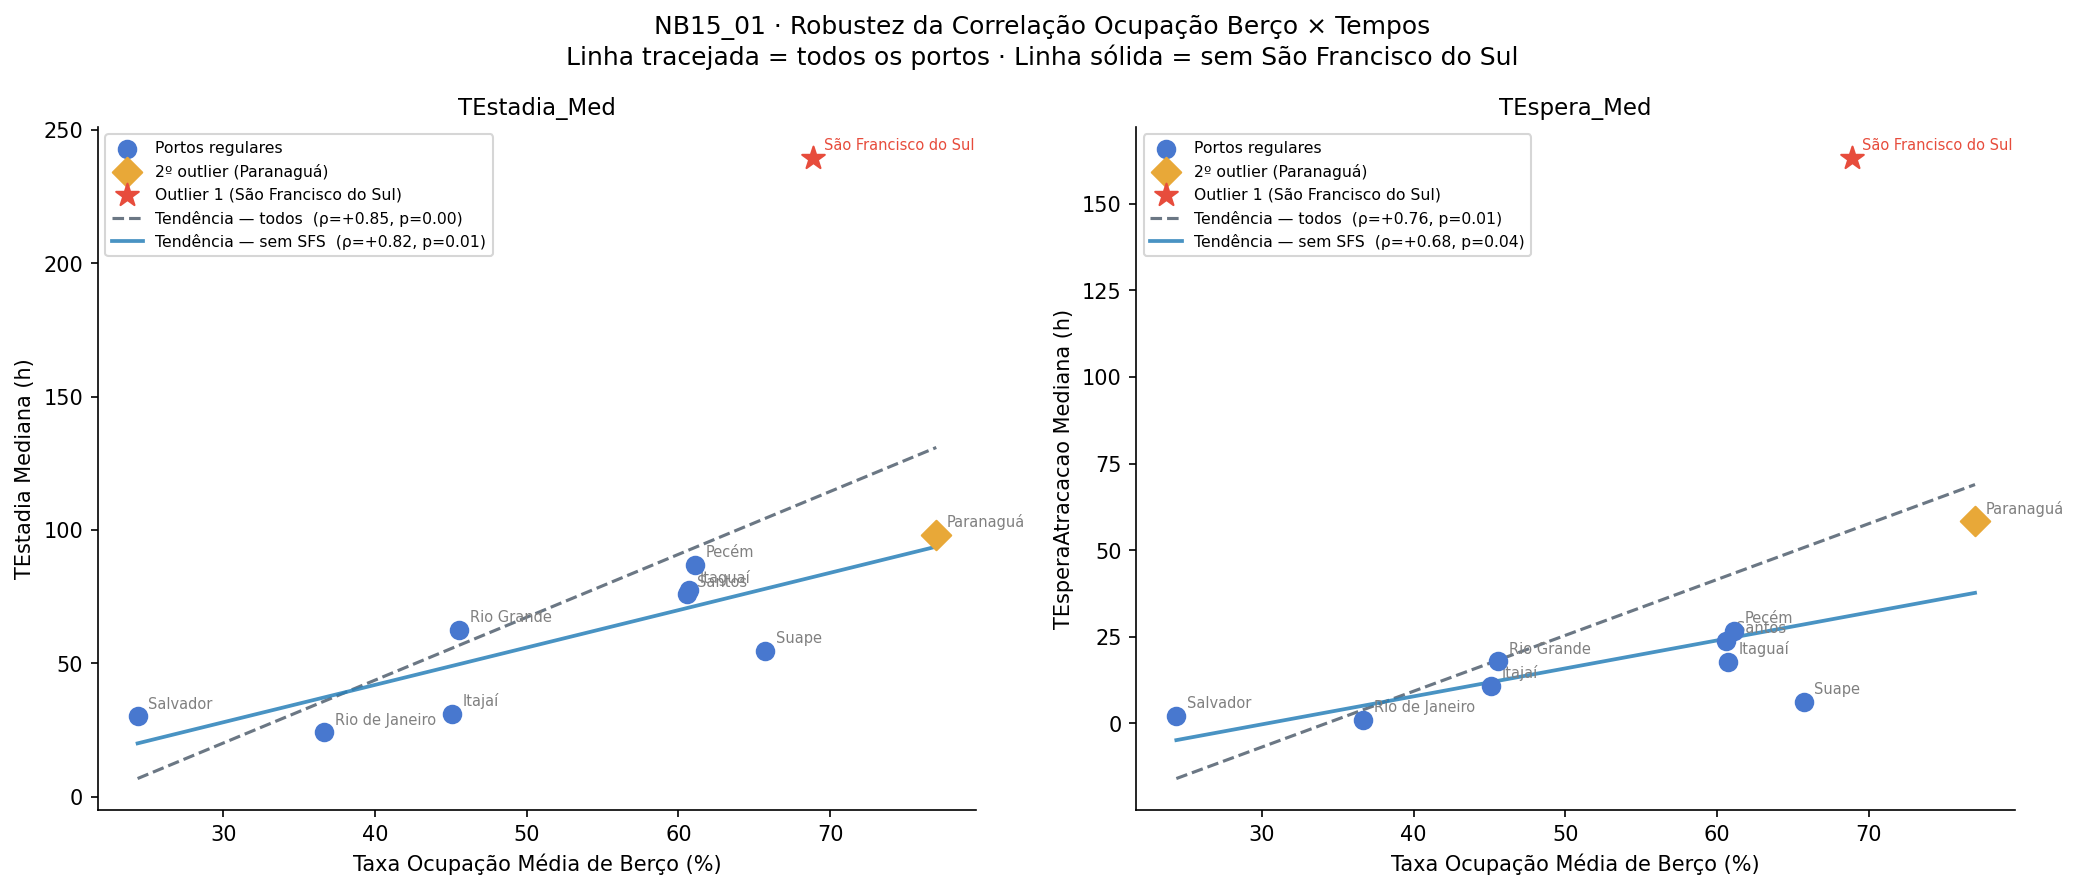

Salvo: nb15_01_scatter_robustez_correlacao.png


In [4]:
# ── Figura nb15_01: Scatter com 3 linhas de tendência ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax_i, (y_col, y_label, rho_A, rho_B, p_A, p_B) in enumerate([
    ('TEstadia_Med', 'TEstadia Mediana (h)', rho_est_A, rho_est_B, p_est_A, p_est_B),
    ('TEspera_Med',  'TEsperaAtracacao Mediana (h)', rho_esp_A, rho_esp_B, p_esp_A, p_esp_B),
]):
    ax = axes[ax_i]
    valid = df.dropna(subset=['Taxa_Media_Pct', y_col])

    is_out1 = valid['Porto_Canon'] == outlier_1['Porto_Canon']
    is_out2 = valid['Porto_Canon'] == outlier_2['Porto_Canon']
    is_normal = ~is_out1 & ~is_out2

    # Pontos normais
    ax.scatter(valid.loc[is_normal, 'Taxa_Media_Pct'],
               valid.loc[is_normal, y_col],
               color='#4878CF', s=70, zorder=5, label='Portos regulares')

    # 2º outlier
    ax.scatter(valid.loc[is_out2, 'Taxa_Media_Pct'],
               valid.loc[is_out2, y_col],
               color='#E8A838', s=100, zorder=6, marker='D', label=f'2º outlier ({outlier_2["Porto_Canon"]})')

    # 1º outlier (São Francisco do Sul)
    ax.scatter(valid.loc[is_out1, 'Taxa_Media_Pct'],
               valid.loc[is_out1, y_col],
               color='#E74C3C', s=130, zorder=7, marker='*', label=f'Outlier 1 ({outlier_1["Porto_Canon"]})')

    # Anotações
    for _, row in valid.iterrows():
        offset = (5, 4)
        ax.annotate(row['Porto_Canon'],
                    (row['Taxa_Media_Pct'], row[y_col]),
                    textcoords='offset points', xytext=offset, fontsize=7,
                    color='#E74C3C' if row['Porto_Canon'] == outlier_1['Porto_Canon'] else 'gray')

    # ── Linha de tendência A: todos ────────────────────────────────────────
    x_all = valid['Taxa_Media_Pct'].values
    y_all = valid[y_col].values
    z_A = np.polyfit(x_all, y_all, 1)
    x_line = np.linspace(x_all.min(), x_all.max(), 50)
    ax.plot(x_line, np.polyval(z_A, x_line),
            '--', color='#2C3E50', lw=1.5, alpha=0.7,
            label=f'Tendência — todos  (ρ={rho_A:+.2f}, p={p_A:.2f})')

    # ── Linha de tendência B: sem outlier 1 ───────────────────────────────
    valid_B = valid[~is_out1]
    if len(valid_B) >= 3:
        x_B = valid_B['Taxa_Media_Pct'].values
        y_B = valid_B[y_col].values
        z_B = np.polyfit(x_B, y_B, 1)
        x_line_B = np.linspace(x_B.min(), x_B.max(), 50)
        ax.plot(x_line_B, np.polyval(z_B, x_line_B),
                '-', color='#2980B9', lw=1.8, alpha=0.85,
                label=f'Tendência — sem SFS  (ρ={rho_B:+.2f}, p={p_B:.2f})')

    ax.set_xlabel('Taxa Ocupação Média de Berço (%)', fontsize=10)
    ax.set_ylabel(y_label, fontsize=10)
    ax.set_title(f'{y_col}', fontsize=11)
    ax.legend(fontsize=7.5, loc='upper left')

fig.suptitle('NB15_01 · Robustez da Correlação Ocupação Berço × Tempos\n'
             'Linha tracejada = todos os portos · Linha sólida = sem São Francisco do Sul',
             fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR + 'nb15_01_scatter_robustez_correlacao.png', dpi=150)
plt.show()
print('Salvo: nb15_01_scatter_robustez_correlacao.png')

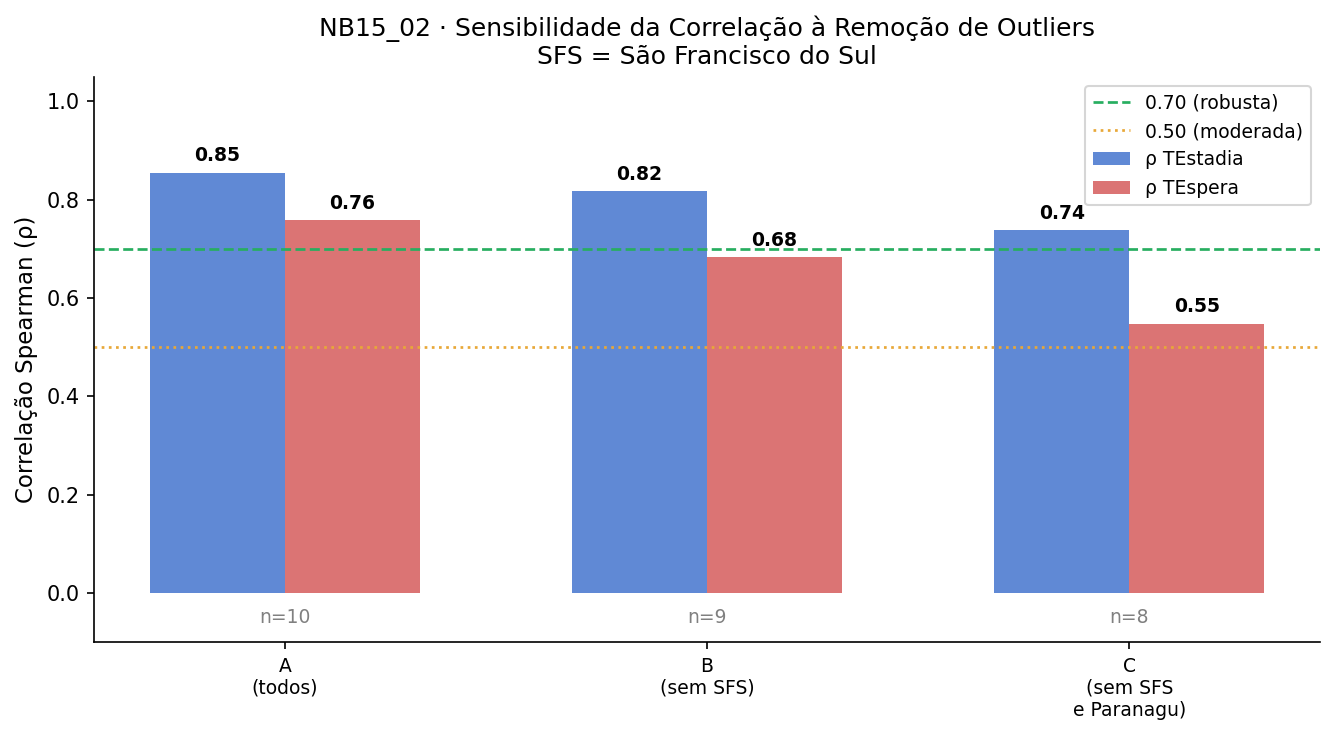

Salvo: nb15_02_sensibilidade_rho_cenarios.png


In [5]:
# ── Figura nb15_02: Comparação ρ por cenário ─────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

cenarios = ['A\n(todos)', f'B\n(sem SFS)', f'C\n(sem SFS\ne {outlier_2["Porto_Canon"][:8]})']
rhos_est = [rho_est_A, rho_est_B, rho_est_C]
rhos_esp = [rho_esp_A, rho_esp_B, rho_esp_C]
x_c = np.arange(len(cenarios))
w_c = 0.32

bars_est = ax.bar(x_c - w_c/2, rhos_est, w_c, label='ρ TEstadia', color='#4878CF', alpha=0.87)
bars_esp = ax.bar(x_c + w_c/2, rhos_esp, w_c, label='ρ TEspera',  color='#D65F5F', alpha=0.87)

# Linhas de threshold
ax.axhline(0.70, color='#27AE60', ls='--', lw=1.3, label='0.70 (robusta)')
ax.axhline(0.50, color='#E8A838', ls=':',  lw=1.3, label='0.50 (moderada)')

# Anotar valores
for bars, rhos in [(bars_est, rhos_est), (bars_esp, rhos_esp)]:
    for bar, rho in zip(bars, rhos):
        if not np.isnan(rho):
            ax.text(bar.get_x() + bar.get_width()/2,
                    rho + 0.015,
                    f'{rho:.2f}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

# Anotar n de portos
for idx, n_val in enumerate([n_A, n_B, n_C]):
    ax.text(idx, -0.06, f'n={n_val}', ha='center', fontsize=9, color='gray')

ax.set_xticks(x_c)
ax.set_xticklabels(cenarios, fontsize=9)
ax.set_ylabel('Correlação Spearman (ρ)', fontsize=11)
ax.set_ylim(-0.1, 1.05)
ax.set_title('NB15_02 · Sensibilidade da Correlação à Remoção de Outliers\n'
             'SFS = São Francisco do Sul', fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR + 'nb15_02_sensibilidade_rho_cenarios.png', dpi=150)
plt.show()
print('Salvo: nb15_02_sensibilidade_rho_cenarios.png')

---
## 4 — Conclusão

In [6]:
# ── Conclusão programática ────────────────────────────────────────────────
print('=' * 65)
print('CONCLUSÃO — TESTE DE ROBUSTEZ')
print('=' * 65)
print()

# São Francisco do Sul
print(f'OUTLIER PRINCIPAL: São Francisco do Sul')
print(f'  TEstadia = {outlier_1["TEstadia_Med"]:.0f}h  ({ratio_12:.1f}× acima do 2º outlier)')
print(f'  TEspera  = {outlier_1["TEspera_Med"]:.0f}h')
print(f'  Causa estrutural: rota Ásia—SFS dominada por graneleiros especializados')
print(f'  com operações longas (>200h) — não representativo de porto container típico.')
print()

# Veredicto por métrica
for metrica, rho_A, rho_B, rho_C in [
    ('TEstadia', rho_est_A, rho_est_B, rho_est_C),
    ('TEspera',  rho_esp_A, rho_esp_B, rho_esp_C),
]:
    delta_AB = rho_B - rho_A
    veredicto_B = interpret(rho_B)
    print(f'--- ρ {metrica} ---')
    print(f'  Cenário A (n={n_A}): ρ={rho_A:+.3f}')
    print(f'  Cenário B (n={n_B}): ρ={rho_B:+.3f}  Δ={delta_AB:+.3f} vs A')
    print(f'  Cenário C (n={n_C}): ρ={rho_C:+.3f}')
    print(f'  → VEREDICTO (Cenário B): {veredicto_B}')
    print()

print('DECLARAÇÃO OBRIGATÓRIA:')
print(f'  n={n_A} portos é amostra pequena. Mesmo ρ alto não implica causalidade.')
print('  Interpretar com cautela independentemente do valor de ρ.')
print('  Correlação Spearman detecta associação monotónica, não relação linear causal.')

# Salvar tabela
tab.to_csv(CSV_DIR + 'robustez_correlacao_ocupacao_testadia.csv', index=False, encoding='utf-8-sig')
print()
print('Salvo: robustez_correlacao_ocupacao_testadia.csv')

CONCLUSÃO — TESTE DE ROBUSTEZ

OUTLIER PRINCIPAL: São Francisco do Sul
  TEstadia = 240h  (2.4× acima do 2º outlier)
  TEspera  = 163h
  Causa estrutural: rota Ásia—SFS dominada por graneleiros especializados
  com operações longas (>200h) — não representativo de porto container típico.

--- ρ TEstadia ---
  Cenário A (n=10): ρ=+0.855
  Cenário B (n=9): ρ=+0.817  Δ=-0.038 vs A
  Cenário C (n=8): ρ=+0.738
  → VEREDICTO (Cenário B): Robusta — publicável

--- ρ TEspera ---
  Cenário A (n=10): ρ=+0.758
  Cenário B (n=9): ρ=+0.683  Δ=-0.075 vs A
  Cenário C (n=8): ρ=+0.548
  → VEREDICTO (Cenário B): Moderada — publicar com ressalva

DECLARAÇÃO OBRIGATÓRIA:
  n=10 portos é amostra pequena. Mesmo ρ alto não implica causalidade.
  Interpretar com cautela independentemente do valor de ρ.
  Correlação Spearman detecta associação monotónica, não relação linear causal.

Salvo: robustez_correlacao_ocupacao_testadia.csv
